In [45]:
import requests
import gzip
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt 

In [4]:
url = "https://snap.stanford.edu/data/wiki-Vote.txt.gz"
respuesta = requests.get(url) #descargamos los datos  
with open("datos.txt.gz", "wb") as datos : #Los datos inicialmente vienen en formato gzip
    datos.write(respuesta.content)

In [5]:
#Descomprimir los datos 
with gzip.open("datos.txt.gz", "rt") as archivo_gzip: #Leemos el archivo como string,no como bytes
     grafo = nx.read_edgelist(archivo_gzip, comments="#", delimiter = "\t", nodetype = int,create_using =nx.DiGraph())
    #La linea anterior ,ignora los comentarios ,los saltos de linea y crea usando grafo dirigido 

In [19]:
# ESTADISTICAS
aristas = (grafo.number_of_edges()) #Numero de aristas 
cantidad_nodos = (grafo.number_of_nodes()) 
grado_entrada_medio =  (sum(dict(grafo.in_degree()).values())/cantidad_nodos) #Sumamos la cantidad de entrantes y la dividimos en cantidad de nodos
grado_salida_medio = sum(dict(grafo.out_degree()).values())/cantidad_nodos
nodos_colgantes = sum(1 for nodo in grafo.nodes() if grafo.out_degree(nodo) == 0) #Sin aristas de salida
densidad_red = aristas / (cantidad_nodos * (cantidad_nodos-1))

In [21]:
# nodo de mayor grado 
valores_grados_nodos = dict(grafo.in_degree())
nodo_mayor_grado_entrada = int(max(valores_grados_nodos, key = valores_grados_nodos.get))
print(F"El nodo {nodo_mayor_grado_entrada}  tiene {max(valores_grados_nodos.values())} conexiones que llegan a el  ")

El nodo 4037  tiene 457 conexiones que llegan a el  


In [27]:
estadisticas = pd.DataFrame(data = {"Metricas" : ["Cantidad aristas","Cantidad de nodos",
                                                  "Grado_entrada_medio","Grado_salida_medio",
                                                  "Nodo_mayor_grado_entrada","Cantidad_Nodos_Colgantes",
                                                  "Densidad de la red"],
                                   "Valor" : [(aristas), cantidad_nodos,grado_entrada_medio,
                                              grado_salida_medio, nodo_mayor_grado_entrada, 
                                              nodos_colgantes ,densidad_red]})
estadisticas

,Metricas,Valor
0,Cantidad aristas,103689.000000
1,Cantidad de nodos,7115.000000
2,Grado_entrada_medio,14.573296
3,Grado_salida_medio,14.573296
4,Nodo_mayor_grado_entrada,4037.000000
5,Cantidad_Nodos_Colgantes,1005.000000
6,Densidad de la red,0.002049


# Que la densidad de la red sea más cercana a 0,quiere decir que la mayoria de los nodos estan separados entre si .Si fuera mas cercana a 1,significaria que la mayoria esta conectados entre si.

# P3 

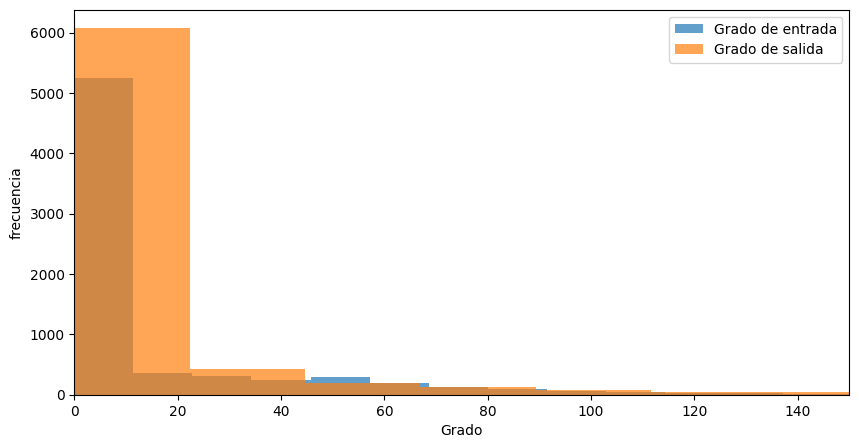

In [67]:
# Grafico de distribución de grado de entrda y del grado de salida  
grado_entrada = list(dict(grafo.in_degree()).values())
grado_salida = list(dict(grafo.out_degree()).values())
plt.figure(figsize = (10,5) )
plt.hist(grado_entrada, bins = 40, alpha = 0.7, label = "Grado de entrada")
plt.hist(grado_salida, bins = 40, alpha = 0.7, label = "Grado de salida")
plt.xlim(0,150)
plt.legend()
plt.ylabel("frecuencia")
plt.xlabel("Grado")
plt.show()

# Bibliografía : 
- Recursos python. (2021). Compresión y descompresión de archivos zip, gz y bz2. Recursos python. https://recursospython.com/guias-y-manuales/compresion-y-descompresion-de-archivos/
- Carazo,F. & Amat,Joaquin. (2024). Métricas de Grafos y Redes. Ciencia de datos. https://cienciadedatos.net/documentos/pygml04-metricas-grafos-redes-python
- Moiz, M.S . (2023). Cómo encontrar el valor máximo en el Diccionario Python. DelftStack. https://www.delftstack.com/es/howto/python/find-max-value-in-dictionary-python/ 